<a href="https://colab.research.google.com/github/nisal-eng/Statistical-Learning-e22206/blob/main/Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q. Analytical Derivation**

Given ModelState equation: $x_k = A_k x_{k-1} + q_k, \quad q_k \sim \mathcal{N}(0, Q_k)$Measurement equation: $y_k = H_k x_k + r_k, \quad r_k \sim \mathcal{N}(0, R_k)$Prior: $x_{k-1} \mid y_{1:k-1} \sim \mathcal{N}(m_{k-1}, P_{k-1})$





### **Step 1: Predictive State Distribution**

We want to show that $p(x_k \mid y_{1:k-1}) = \mathcal{N}(x_k \mid m_k^-, P_k^-)$.
Because the state transition is a linear transformation of a Gaussian variable plus an independent Gaussian noise vector, $x_k$ remains Gaussian. We find its parameters using the linearity of expectation and covariance:$$\begin{aligned}
m_k^- &= \mathbb{E}[x_k \mid y_{1:k-1}] \\
&= \mathbb{E}[A_k x_{k-1} + q_k \mid y_{1:k-1}] \\
&= A_k \mathbb{E}[x_{k-1} \mid y_{1:k-1}] + \mathbb{E}[q_k] \\
&= A_k m_{k-1}
\end{aligned}$$$$\begin{aligned}
P_k^- &= \text{Cov}(x_k \mid y_{1:k-1}) \\
&= \text{Cov}(A_k x_{k-1} + q_k \mid y_{1:k-1}) \\
&= A_k \text{Cov}(x_{k-1} \mid y_{1:k-1}) A_k^T + \text{Cov}(q_k) \\
&= A_k P_{k-1} A_k^T + Q_k
\end{aligned}$$Thus, $p(x_k \mid y_{1:k-1}) = \mathcal{N}(x_k \mid m_k^-, P_k^-)$.

### **Step 2: Joint Distribution of State and MeasurementWe seek the joint**


distribution $p(x_k, y_k \mid y_{1:k-1})$. Since $y_k = H_k x_k + r_k$, the joint vector $[x_k^T, y_k^T]^T$ is Gaussian.Mean of $y_k$:$$\mathbb{E}[y_k \mid y_{1:k-1}] = \mathbb{E}[H_k x_k + r_k \mid y_{1:k-1}] = H_k m_k^-$$Covariance of $y_k$:$$\begin{aligned}
S_k = \text{Cov}(y_k \mid y_{1:k-1}) &= \text{Cov}(H_k x_k + r_k \mid y_{1:k-1}) \\
&= H_k P_k^- H_k^T + R_k
\end{aligned}$$Cross-covariance:$$\begin{aligned}
\text{Cov}(x_k, y_k \mid y_{1:k-1}) &= \mathbb{E}[(x_k - m_k^-)(y_k - H_k m_k^-)^T \mid y_{1:k-1}] \\
&= \mathbb{E}[(x_k - m_k^-)(H_k(x_k - m_k^-) + r_k)^T \mid y_{1:k-1}] \\
&= P_k^- H_k^T
\end{aligned}$$Putting it together:$$\begin{bmatrix} x_k \\ y_k \end{bmatrix} \;\Bigg|\; y_{1:k-1} \sim \mathcal{N}\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & S_k \end{bmatrix} \right)$$

### **Step 3: Predictive Measurement Distribution**

From the joint distribution above, the marginal distribution of $y_k$ given past data is simply the lower component:$$p(y_k \mid y_{1:k-1}) = \mathcal{N}(y_k \mid H_k m_k^-, S_k)$$where $S_k = H_k P_k^- H_k^T + R_k$.

### **Step 4: Posterior State Distribution (The Update Step)**

Using the standard Gaussian conditioning identities for a joint distribution $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix}\right)$, the conditional distribution $X \mid Y=y$ is $\mathcal{N}(\mu_{X \mid Y}, \Sigma_{X \mid Y})$ where:$$\mu_{X \mid Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$$$\Sigma_{X \mid Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$Mapping our variables ($X \to x_k$, $Y \to y_k$):Kalman Gain: $K_k = \Sigma_{XY}\Sigma_{YY}^{-1} = P_k^- H_k^T S_k^{-1}$Updated Mean: $m_k = m_k^- + K_k(y_k - H_k m_k^-)$Updated Covariance: $P_k = P_k^- - K_k S_k K_k^T = P_k^- - K_k H_k P_k^-$ (or $(I - K_k H_k)P_k^-$)Thus, $p(x_k \mid y_{1:k}) = \mathcal{N}(x_k \mid m_k, P_k)$.

### **Step 5: Identification of $G_k$ and $W_k$**

If given an alternative formatting algebraic equivalence such as $m_k = G_k m_{k-1} + W_k y_k$:Substituting $m_k^- = A_k m_{k-1}$:$$m_k = (I - K_k H_k)A_k m_{k-1} + K_k y_k$$Therefore:$G_k = (I - K_k H_k)A_k$$W_k = K_k = P_k^- H_k^T S_k^{-1}$

# **Q.1-D Example**

Given Scalar Values
$x_k = a x_{k-1} + q_k, \quad q_k \sim \mathcal{N}(0, q)$$y_k = h x_k + r_k, \quad r_k \sim \mathcal{N}(0, r)$$x_{k-1} \mid y_{1:k-1} \sim \mathcal{N}(m_{k-1}, P_{k-1})$Definitions:

$m_k^- = a m_{k-1}$ and $P_k^- = a^2 P_{k-1} + q$Deriving the ExpressionsApplying the general 1D scalar equivalents directly:

1. Predictive Measurement Distribution (Before seeing $y_k$)From Step 3, substituting scalars:$$p(y_k \mid y_{1:k-1}) = \mathcal{N}(y_k \mid h m_k^-, h^2 P_k^- + r)$$

2. Posterior-Predictive Measurement Distribution (After filtering on $y_k$)This evaluates the distribution of a new measurement at the same step after updating the state estimate with $y_k$:$$p(y_k^* \mid y_{1:k}) = \mathcal{N}(y_k^* \mid h m_k, h^2 P_k + r)$$Where:$$K_k = \frac{h P_k^-}{h^2 P_k^- + r}$$$$m_k = m_k^- + K_k(y_k - h m_k^-)$$$$P_k = (1 - K_k h)P_k^-$$

The following code visualize how the distributions shift from prior to predictive and posterior.



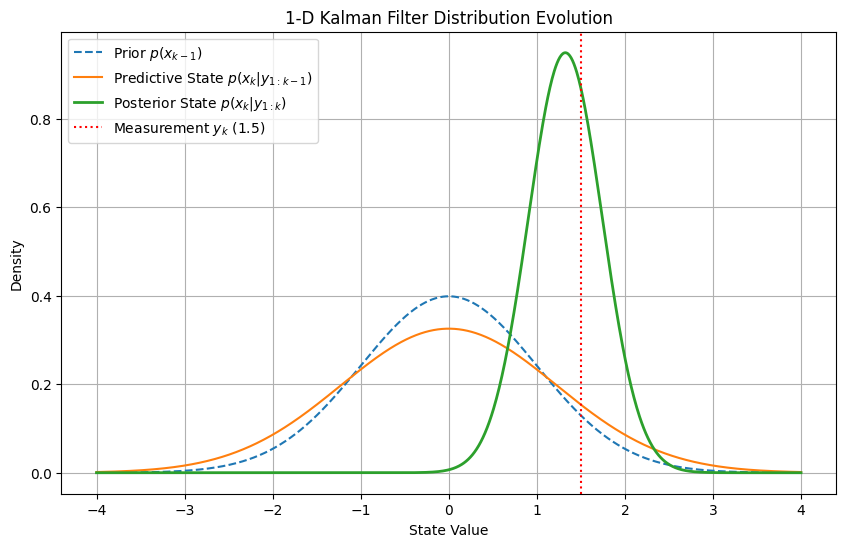

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
a, h = 1.0, 1.0
q, r = 0.5, 0.2
m_prev, P_prev = 0.0, 1.0
y_k = 1.5  # Observed measurement

# Kalman Step Calculations
m_k_minus = a * m_prev
P_k_minus = a**2 * P_prev + q

S_k = h**2 * P_k_minus + r
K_k = (h * P_k_minus) / S_k
m_k = m_k_minus + K_k * (y_k - h * m_k_minus)
P_k = (1 - K_k * h) * P_k_minus

# Plotting
x = np.linspace(-4, 4, 1000)
plt.figure(figsize=(10, 6))
plt.plot(x, norm.pdf(x, m_prev, np.sqrt(P_prev)), label='Prior $p(x_{k-1})$', linestyle='--')
plt.plot(x, norm.pdf(x, m_k_minus, np.sqrt(P_k_minus)), label='Predictive State $p(x_k|y_{1:k-1})$')
plt.plot(x, norm.pdf(x, m_k, np.sqrt(P_k)), label='Posterior State $p(x_k|y_{1:k})$', lw=2)
plt.axvline(y_k, color='red', linestyle=':', label=f'Measurement $y_k$ ({y_k})')

plt.title('1-D Kalman Filter Distribution Evolution')
plt.xlabel('State Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# **Q.2D-Position Estimation**

**Part A:**

Verification of Matrix OperationsGiven:

$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad P = \begin{bmatrix} P_{11} & P_{12} & P_{13} & P_{14} \\ P_{21} & P_{22} & P_{23} & P_{24} \\ P_{31} & P_{32} & P_{33} & P_{34} \\ P_{41} & P_{42} & P_{43} & P_{44} \end{bmatrix}$$

We calculate $A P A^T$ explicitly:

$$AP = \begin{bmatrix} P_{11} + \Delta t P_{31} & P_{12} + \Delta t P_{32} & P_{13} + \Delta t P_{33} & P_{14} + \Delta t P_{34} \\
P_{21} + \Delta t P_{41} & P_{22} + \Delta t P_{42} & P_{23} + \Delta t P_{43} & P_{24} + \Delta t P_{44} \\
P_{31} & P_{32} & P_{33} & P_{34} \\
P_{41} & P_{42} & P_{43} & P_{44} \end{bmatrix}$$


Multiplying $(AP)$ by $A^T$:

$$A^T = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ \Delta t & 0 & 1 & 0 \\ 0 & \Delta t & 0 & 1 \end{bmatrix}$$

Yields the expected form for $A P A^T$:

$$\begin{bmatrix}
P_{11} + \Delta t(P_{31}+P_{13}) + \Delta t^2 P_{33} & P_{12} + \Delta t P_{32} + \Delta t P_{14} + \Delta t^2 P_{34} & P_{13} + \Delta t P_{33} & P_{14} + \Delta t P_{34} \\
P_{21} + \Delta t P_{12} + \Delta t P_{42} + \Delta t^2 P_{43} & P_{22} + \Delta t(P_{42}+P_{24}) + \Delta t^2 P_{44} & P_{23} + \Delta t P_{43} & P_{24} + \Delta t P_{44} \\
P_{31} + \Delta t P_{33} & P_{32} + \Delta t P_{34} & P_{33} & P_{34} \\
P_{41} + \Delta t P_{43} & P_{42} + \Delta t P_{44} & P_{43} & P_{44}
\end{bmatrix}$$

Given symmetry ($P_{ij} = P_{ji}$), this directly matches the target block expansions for $A P_{k-1} A^T$.

Now, for $H P^- H^T$ and $H P^-$, where $H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$:

$$H P^- = \begin{bmatrix} P^-_{11} & P^-_{12} & P^-_{13} & P^-_{14} \\ P^-_{21} & P^-_{22} & P^-_{23} & P^-_{24} \end{bmatrix}$$

$$H P^- H^T = \begin{bmatrix} P^-_{11} & P^-_{12} \\ P^-_{21} & P^-_{22} \end{bmatrix}$$Adding $R_k = \begin{bmatrix} \sigma_1^2 & 0 \\ 0 & \sigma_2^2 \end{bmatrix}$ yields:$$S_k = H P^- H^T + R_k = \begin{bmatrix} P^-_{11} + \sigma_1^2 & P^-_{12} \\ P^-_{21} & P^-_{22} + \sigma_2^2 \end{bmatrix}$$

**Part B:**

Python Implementation for GPS Filtering

Below code is a Python implementation using numpy to handle the constant-velocity tracking system.

In [2]:
import numpy as np

class GPSKalmanFilter2D:
    def __init__(self, dt, q_var, r_var_x, r_var_y):
        self.dt = dt

        # State Vector: [x, y, vx, vy]^T
        self.m = np.zeros((4, 1))

        # Initial State Covariance
        self.P = np.eye(4) * 1000.0  # high uncertainty initially

        # Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Covariance (Q) - Piecewise white noise model
        self.Q = np.array([
            [0.25*dt**4, 0,           0.5*dt**3,  0],
            [0,           0.25*dt**4, 0,           0.5*dt**3],
            [0.5*dt**3,  0,           dt**2,       0],
            [0,           0.5*dt**3,  0,           dt**2]
        ]) * q_var

        # Measurement Noise Covariance (R)
        self.R = np.array([
            [r_var_x, 0],
            [0, r_var_y]
        ])

    def filter_sequence(self, measurements):
        """
        Filters an array of noisy measurements.
        measurements: shape (N, 2) array of [[x1, y1], [x2, y2], ...]
        """
        N = len(measurements)
        filtered_states = np.zeros((N, 4))

        # Initialize state with first measurement if available
        if N > 0:
            self.m[0, 0] = measurements[0, 0]
            self.m[1, 0] = measurements[0, 1]
            filtered_states[0] = self.m.flatten()

        for k in range(1, N):
            # 1. Predict
            m_minus = self.A @ self.m
            P_minus = self.A @ self.P @ self.A.T + self.Q

            # 2. Update
            y = measurements[k].reshape(2, 1)
            S = self.H @ P_minus @ self.H.T + self.R
            K = P_minus @ self.H.T @ np.linalg.inv(S)

            self.m = m_minus + K @ (y - self.H @ m_minus)
            self.P = (np.eye(4) - K @ self.H) @ P_minus

            filtered_states[k] = self.m.flatten()

        return filtered_states

# Example usage:
if __name__ == "__main__":
    # Generate mock trajectory data
    np.random.seed(42)
    timesteps = 50
    true_x = np.linspace(0, 100, timesteps)
    true_y = np.linspace(0, 50, timesteps)

    noisy_measurements = np.stack([
        true_x + np.random.normal(0, 2.5, timesteps),
        true_y + np.random.normal(0, 2.5, timesteps)
    ], axis=1)

    # Instantiate filter
    kf = GPSKalmanFilter2D(dt=1.0, q_var=0.1, r_var_x=6.25, r_var_y=6.25)
    filtered_results = kf.filter_sequence(noisy_measurements)

    print("Filtering completed. Sample output (Estimated Positions x, y):")
    print(filtered_results[:5, :2])

Filtering completed. Sample output (Estimated Positions x, y):
[[1.24178538 0.81020992]
 [1.69374322 0.06004669]
 [5.6554384  0.34054121]
 [9.86505442 3.91084149]
 [9.49231526 6.50707856]]
